In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from aeon.visualisation import plot_critical_difference

plt.rcParams['text.usetex'] = True

rename_map = {
    'RuleCard': r'\textsc{rulec}',
    'ScoreCard': r'\textsc{rulec}',
    'ScoreCard2': 'RC2',
    'ScoreCard3': 'RC3',
    'EBM': r'\textsc{ebm}',
    'FIGS': r'\textsc{figs}',
    'TreeGAMCl': r'\textsc{tgam}',
    'fasterrisk': r'\textsc{fr}',
    'fasterriskBin': r'\textsc{fr}',
    'LogisticGAM': r'\textsc{lgam}',
    'ridge': r'\textsc{rid}',
    'log_reg': r'\textsc{lre}',
    #'EBM+LASSO': r'EBM-L',
    #'slimrisk': r'SLIM',
    #'Apriori+Log_reg': r'A-LR',
    'boley': r'\textsc{opt}',
    'apriori_log': r'\textsc{a-lre}',
    'apriori_ridge': r'\textsc{a-rid}',
    'rulefit': r'\textsc{rulef}',
    'RF': r'\textsc{rf}',
    'dt': r'\textsc{dt}',
    'lgbm': r'\textsc{lgbm}',
    'xgboost': r'\textsc{xgb}',
    'EBMLasso': r'\textsc{ebm}$_{l}$',
    'EBMSweep': r'\textsc{ebm}$_{s}$'
}

In [35]:
df = pd.read_csv("df_best_final_all_metrics.csv")

df

,dataset_name,model_name,learning_rate,patience,max_depth,max_n_iter,feature_order,recompute_feature_order,reuse_features,use_fast,top_k_features,n_jobs,feature_importance_estimator,cv_fit_time,cv_predict_time,val_accuracy,val_balanced_accuracy,val_f1_score,val_f1_micro,val_f1_macro,val_f1_weighted,val_precision_score,val_precision_micro,val_precision_macro,val_precision_weighted,val_recall_score,val_recall_micro,val_recall_macro,val_recall_weighted,val_roc_macro,val_roc_micro,val_roc_weighted,val_average_precision_macro,val_average_precision_micro,val_average_precision_weighted,fit_time,predict_time,accuracy,balanced_accuracy,f1_score,...,interactions,validation_size,terms,max_iter,tol,Unnamed: 0,PDO,odds0,score0,n_rules,n_feature_used,boosting_type,num_leaves,n_boosting_rounds,max_leaf_nodes,reg_param,n_boosting_rounds_marginal,max_leaf_nodes_marginal,reg_param_marginal,fit_linear_marginal,boosting_strategy,validation_frac,l1_ratio,dual,num_rules,rfmode,max_rules,memory_par,model_type,max_trees,min_impurity_decrease,max_features,fi_global,fi_local,rb_global,rb_local,brier_score,log_loss,ece,mce
0,adult,EBM,0.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,574.398680,0.038877,0.173423,0.159044,0.141930,0.173423,0.162349,0.172596,0.155707,0.173423,0.166900,0.172516,0.130392,0.173423,0.159044,0.173423,0.184788,0.184788,0.184788,0.164901,0.164901,0.164901,122.387237,0.010397,0.874349,0.806471,0.726822,...,3x,0.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36134.0,136.000000,3755.0,238.000000,0.742155,3.894763,0.750869,0.978774
1,adult,EBMLasso,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,7176.745263,0.071815,0.086772,0.124552,0.093573,0.086772,0.086308,0.082663,0.061089,0.086772,0.130435,0.165234,0.199837,0.086772,0.124552,0.086772,0.183294,0.183294,0.183294,0.162257,0.162257,0.162257,925.858459,0.017103,0.430176,0.619301,0.465415,...,3x,0.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12578.0,39.000000,620.0,55.000000,0.268340,0.733940,0.383368,0.736558
2,adult,EBMSweep,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,1381.104139,0.114132,0.173341,0.158881,0.141700,0.173341,0.162210,0.172503,0.155621,0.173341,0.166811,0.172426,0.130065,0.173341,0.158881,0.173341,0.184719,0.184719,0.184719,0.164735,0.164735,0.164735,360.398251,0.013295,0.874512,0.805924,0.726499,...,3x,0.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36098.0,136.000000,3731.0,238.000000,0.740545,3.730345,0.750018,0.975964
3,adult,FIGS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77.671409,0.286642,0.171958,0.155939,0.137562,0.171958,0.159740,0.170870,0.154425,0.171958,0.165384,0.170883,0.124020,0.171958,0.155939,0.171958,0.181261,0.181261,0.181261,0.158478,0.158478,0.158478,19.602996,0.078597,0.866699,0.788053,0.702290,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,293.0,17.388889,0.431029,1.083253,0.538256,0.838085
4,adult,LogisticGAM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1460.829336,1.399692,0.170085,0.153928,0.133933,0.170085,0.157299,0.169025,0.148851,0.170085,0.162184,0.168875,0.121732,0.170085,0.153928,0.170085,0.181733,0.181733,0.181733,0.156550,0.156550,0.156550,64.834157,0.402256,0.861328,0.789282,0.698727,...,NaN,NaN,auto,100.0,0.0001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,680.0,107.543623,NaN,NaN,0.096749,0.303855,0.011717,0.039733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
216,titanic,lgbm,

In [36]:
df.brier_score

0      0.742155
1      0.268340
2      0.740545
3      0.431029
4      0.096749
         ...   
216    0.610544
217    0.536572
218    0.379697
219         NaN
220    0.613054
Name: brier_score, Length: 221, dtype: float64

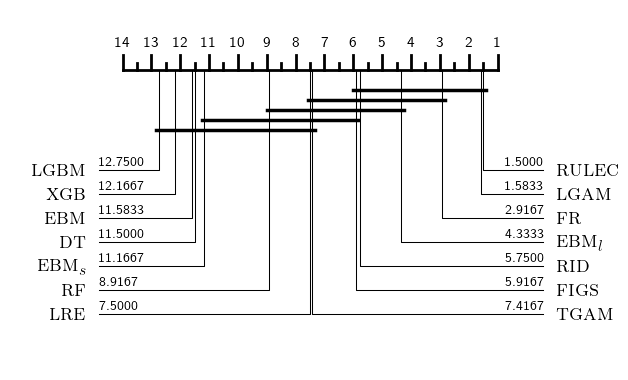

In [42]:
to_drop = ['rulefit', 'boley', 'fasterrisk', 'apriori_log', 'apriori_ridge']

df_pivot = df.pivot(index='dataset_name', columns='model_name', values='brier_score').drop(columns=to_drop)

df_pivot = df_pivot.fillna(1.)

plot_critical_difference(df_pivot.values, [rename_map[x] for x in df_pivot.columns], 
                         lower_better=True, test='nemenyi', alpha=.1)

plt.savefig('cd_brier_score.svg', dpi=600, bbox_inches='tight')

In [38]:
[x for x in df.columns if 'global' in x]

['fi_global', 'rb_global']

In [39]:
df.groupby('model_name')[['rb_global', 'rb_local', 'fi_global', 'fi_local']].agg(['mean', 'std']).round().style.format('{:.0f}').to_excel('tmp.xlsx')

brier_score


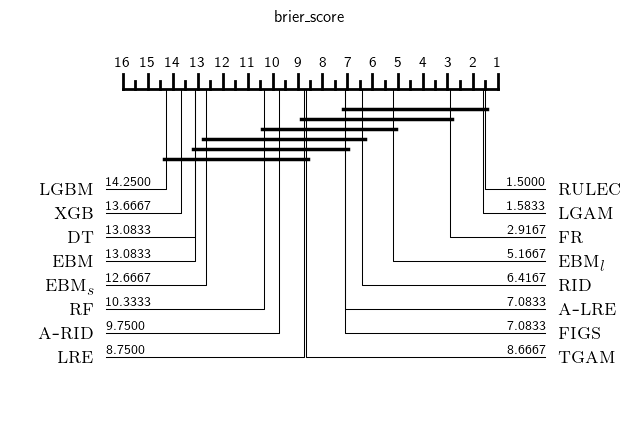

log_loss


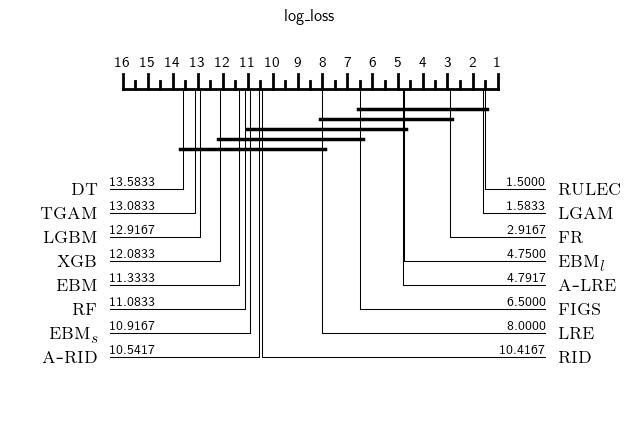

ece


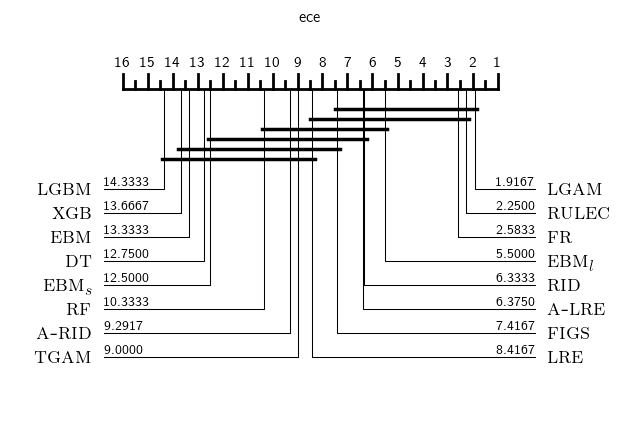

mce


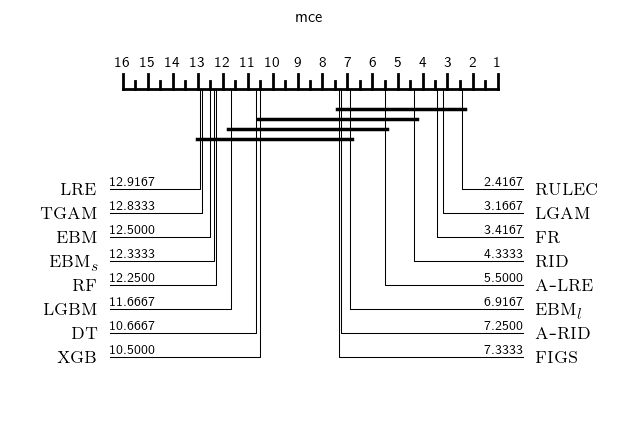

In [40]:
for col in ['brier_score', 'log_loss', 'ece', 'mce']:
    to_drop = ['rulefit', 'boley', 'fasterrisk']

    df_pivot = df.pivot(index='dataset_name', columns='model_name', values=col).drop(columns=to_drop)
    
    df_pivot = df_pivot.fillna(1.)
    
    plot_critical_difference(df_pivot.values, [rename_map[x] for x in df_pivot.columns], 
                             lower_better=True, test='nemenyi', alpha=.1)
    
    #plt.savefig('cd_brier_score.png', dpi=600, bbox_inches='tight')
    print(col)
    plt.title(col)
    plt.show()

In [45]:
df.groupby('model_name')['fit_time'].agg(['mean', 'std']).sort_values('mean')

,mean,std
model_name,,
ridge,0.029861,0.060493
lgbm,0.927090,1.900597
FIGS,4.099711,7.192733
log_reg,5.294796,6.375305
xgboost,6.793027,3.389401
RF,7.970436,19.314185
dt,11.742563,39.648541
EBM,25.022939,38.087297
rulefit,35.987890,70.630098
